### Comparing Aggregate Models for Regression

This try-it focuses on utilizing ensemble models in a regression setting.  Much like you have used individual classification estimators to form an ensemble of estimators -- here your goal is to explore ensembles for regression models.  As with your earlier assignment, you will use scikitlearn to carry out the ensembles using the `VotingRegressor`.   

The Voting regressor model combines various traditional and ensemble ML models in order to improve the accuracy of predictions by mitigating the impact of noise made by each individual models.


#### Dataset and Task

Below, a dataset containing census information on individuals and their hourly wage is loaded usinhttps://www.google.com/url?q=https%3A%2F%2Fwww.openml.org%2Fg the `fetch_openml` function.  OpenML is another repository for datasets [here](https://www.openml.org/).  Your task is to use ensemble methods to explore predicting the `wage` column of the data.  Your ensemble should at the very least consider the following models:

- `LinearRegression` -- perhaps you even want the `TransformedTargetRegressor` here.
- `KNeighborsRegressor`
- `DecisionTreeRegressor`
- `Ridge`
- `SVR`

Tune the `VotingRegressor` to try to optimize the prediction performance and determine if the wisdom of the crowd performed better in this setting than any of the individual models themselves.  Report back on your findings and discuss the interpretability of your findings.  Is there a way to determine what features mattered in predicting wages?

TransformedTargetRegressor is a Meta-estimator to regress on a transformed target.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR# Support Vector Regressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

# Load dataset
survey = fetch_openml(data_id=534, as_frame=True).frame

In [ ]:
# Display the first few rows to understand the data
survey.head()

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8,no,female,21,not_member,5.10,35,Hispanic,Other,Manufacturing,Married
1,9,no,female,42,not_member,4.95,57,White,Other,Manufacturing,Married
2,12,no,male,1,not_member,6.67,19,White,Other,Manufacturing,Unmarried
3,12,no,male,4,not_member,4.00,22,White,Other,Other,Unmarried
4,12,no,male,17,not_member,7.50,35,White,Other,Other,Married


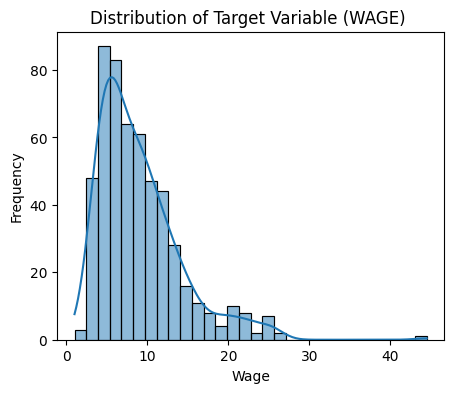

In [4]:
#Quick EDA
survey.isnull().sum()# no nulls founds
surve=survey[~survey.duplicated()]
survey.shape# no duplicates
# plot the distribution of the hourly wage
plt.figure(figsize=(5, 4))
sns.histplot(survey['WAGE'], kde=True)
plt.title('Distribution of Target Variable (WAGE) ')
plt.xlabel('Wage')
plt.ylabel('Frequency')
plt.show()


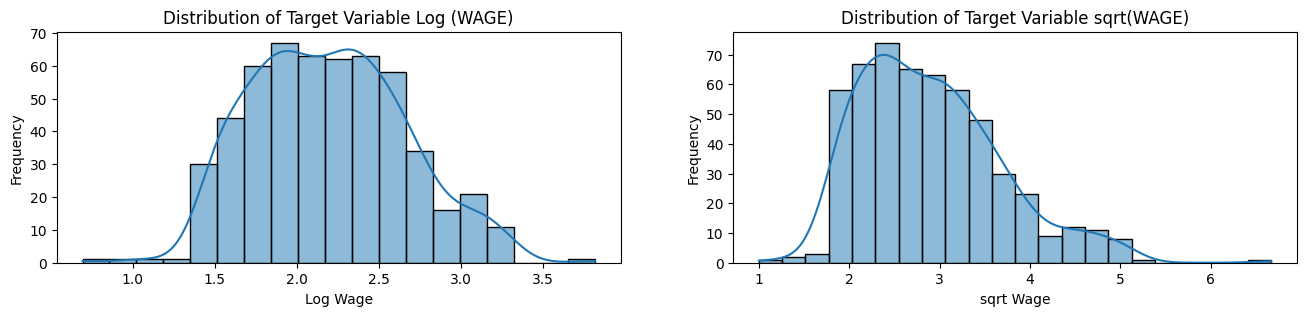

In [5]:
# Distribution comes as left skewed hence we can use TransformTargetRegressor for Ridge and Linear regression models.
# use np.log1p and sqrt transformation to plot the distributions compare and choose the correct one

# plot the distribution of the hourly wage in 2 subplots for sqrt and log1p
plt.figure(figsize=(16, 3))
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(survey['WAGE']), kde=True)
plt.title('Distribution of Target Variable Log (WAGE)')
plt.xlabel('Log Wage')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(np.sqrt(survey['WAGE']), kde=True)
plt.title('Distribution of Target Variable sqrt(WAGE)')
plt.xlabel('sqrt Wage')
plt.ylabel('Frequency')
plt.show()

In [32]:
# Looking at the dist , we would hence pick log1p transform for TransformedTargetRegressor as it is more normal than the sqrt one.
from sklearn.compose import TransformedTargetRegressor
tt = TransformedTargetRegressor(regressor=LinearRegression(),func=np.log1p,inverse_func=np.expm1)

Dataset and Task
Below, a dataset containing census information on individuals and their hourly wage is loaded usinhttps://www.google.com/url?q=https%3A%2F%2Fwww.openml.org%2Fg the fetch_openml function. OpenML is another repository for datasets here. Your task is to use ensemble methods to explore predicting the wage column of the data. Your ensemble should at the very least consider the following models:

LinearRegression -- perhaps you even want the TransformedTargetRegressor here.
KNeighborsRegressor
DecisionTreeRegressor
Ridge
SVR
Tune the VotingRegressor to try to optimize the prediction performance and determine if the wisdom of the crowd performed better in this setting than any of the individual models themselves. Report back on your findings and discuss the interpretability of your findings. Is there a way to determine what features mattered in predicting wages?